# BMI500 Python Quiz

## Problem 1

In [1]:
def leibniz_sum(n):
    total = 0.0
    for k in range(n):
        total += (-1) ** k / (2 * k + 1)
    return total

#Examples for tests
print("4 * S_10 =", 4 * leibniz_sum(10))
print("4 * S_10000 =", 4 * leibniz_sum(10000))

4 * S_10 = 3.0418396189294032
4 * S_10000 = 3.1414926535900345


## Problem 2

### 2a.

In [2]:
def leibniz_modulo(n):
    total = 0.0
    for k in range(n):
        term = 1.0 / (2 * k + 1)
        if k % 2 == 0:
            total += term
        else:
            total -= term
    return total


print("4 * S_10000 =", 4 * leibniz_modulo(10000))

4 * S_10000 = 3.1414926535900345


### 2b.

In [3]:
def leibniz_power(n):
    total = 0.0
    for k in range(n):
        total += (-1) ** k / (2 * k + 1)
    return total


print("4 * S_10000 =", 4 * leibniz_power(10000))

4 * S_10000 = 3.1414926535900345


### 2c.

In [4]:
def leibniz_list(n):
    terms = [(-1) ** k / (2 * k + 1) for k in range(n)]
    return sum(terms)

print("4 * S_10000 =", 4 * leibniz_list(10000))

4 * S_10000 = 3.1414926535900345


### 2d.

In [5]:
def leibniz_set(n):
    terms = {(-1) ** k / (2 * k + 1) for k in range(n)}
    return sum(terms)

print("4 * S_10000 =", 4 * leibniz_set(10000))

4 * S_10000 = 3.1414926535900554


### 2e.

In [6]:
def leibniz_dict(n):
    terms = {k: (-1) ** k / (2 * k + 1) for k in range(n)}
    return sum(terms.values())

print("4 * S_10000 =", 4 * leibniz_dict(10000))

4 * S_10000 = 3.1414926535900345


### 2f.

In [7]:
import numpy as np


def leibniz_numpy(n):
    """Build a NumPy array of the first n terms, then sum it (vectorized)."""
    k = np.arange(n)
    terms = (-1.0) ** k / (2 * k + 1)
    return float(terms.sum())


print("4 * S_10000 =", 4 * leibniz_numpy(10000))

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
4 * S_10000 = 3.1414926535900416


### 2g.

In [8]:
def leibniz_numpy_indexing(n):
    k = np.arange(n)
    terms = (-1.0) ** k / (2 * k + 1)

    positive = terms[::2]
    negative = terms[1::2]

    return float(positive.sum() + negative.sum())


print("4 * S_10000 =", 4 * leibniz_numpy_indexing(10000))

4 * S_10000 = 3.141492653590044


### 2j.

In [9]:
def leibniz_paired(n):
    total = 0.0
    for m in range(n // 2):
        total += 2.0 / ((4 * m + 1) * (4 * m + 3))
    if n % 2 == 1:
        total += 1.0 / (2 * (n - 1) + 1)
    return total


def leibniz_paired_numpy(n):
    m = np.arange(n // 2)
    total = (2.0 / ((4 * m + 1) * (4 * m + 3))).sum()
    if n % 2 == 1:
        total += 1.0 / (2 * n - 1)
    return float(total)


for n in (10000, 10001):
    print(f"4 * alternating = {4*leibniz_power(n)!r}")
    print(f"4 * paired loop = {4*leibniz_paired(n)!r}")
    print(f"4 * paired numpy = {4*leibniz_paired_numpy(n)!r}")

4 * alternating = 3.1414926535900345
4 * paired loop = 3.1414926535900367
4 * paired numpy = 3.1414926535900434
4 * alternating = 3.1416926435905346
4 * paired loop = 3.141692643590537
4 * paired numpy = 3.1416926435905435


## Problem 3

In [10]:
import math
import timeit
import pandas as pd

n = 10000
reference = math.pi

implementations = {
    "2a modulo": leibniz_modulo,
    "2b (-1)**k": leibniz_power,
    "2c list": leibniz_list,
    "2d set": leibniz_set,
    "2e dict": leibniz_dict,
    "2f numpy": leibniz_numpy,
    "2g numpy slicing": leibniz_numpy_indexing,
    "2j paired numpy": leibniz_paired_numpy,
    "2j paired loop": leibniz_paired,
}

repeats = 3
results = []

for name, func in implementations.items():
    seconds = timeit.timeit(lambda f=func: f(n), number=repeats) / repeats

    approx = 4 * func(n)
    error = abs(approx - reference)

    results.append({
        "Implementation": name,
        "4 * S_n": approx,
        "Absolute Error": error,
        "Time (ms)": seconds * 1e3,
    })

df = pd.DataFrame(results)

df = df.sort_values("Time (ms)", ascending=True).reset_index(drop=True)
display(
    df.style.format({
        "4 * S_n": "{:.17f}",
        "Absolute Error": "{:.12e}",
        "Time (ms)": "{:.3f}",
    })
)

df = df.sort_values("Absolute Error", ascending=True).reset_index(drop=True)
display(
    df.style.format({
        "4 * S_n": "{:.17f}",
        "Absolute Error": "{:.12e}",
        "Time (ms)": "{:.3f}",
    })
)

,Implementation,4 * S_n,Absolute Error,Time (ms)
0,2j paired numpy,3.14149265359004337,9.999999974974e-05,0.022
1,2g numpy slicing,3.14149265359004382,9.999999974930e-05,0.089
2,2f numpy,3.14149265359004159,9.999999975152e-05,0.107
3,2j paired loop,3.14149265359003671,9.999999975641e-05,0.502
4,2a modulo,3.14149265359003449,9.999999975863e-05,0.869
5,2b (-1)**k,3.14149265359003449,9.999999975863e-05,1.374
6,2c list,3.14149265359003449,9.999999975863e-05,1.391
7,2e dict,3.14149265359003449,9.999999975863e-05,1.566
8,2d set,3.14149265359005536,9.999999973775e-05,1.945


,Implementation,4 * S_n,Absolute Error,Time (ms)
0,2d set,3.14149265359005536,9.999999973775e-05,1.945
1,2g numpy slicing,3.14149265359004382,9.999999974930e-05,0.089
2,2j paired numpy,3.14149265359004337,9.999999974974e-05,0.022
3,2f numpy,3.14149265359004159,9.999999975152e-05,0.107
4,2j paired loop,3.14149265359003671,9.999999975641e-05,0.502
5,2a modulo,3.14149265359003449,9.999999975863e-05,0.869
6,2b (-1)**k,3.14149265359003449,9.999999975863e-05,1.374
7,2c list,3.14149265359003449,9.999999975863e-05,1.391
8,2e dict,3.14149265359003449,9.999999975863e-05,1.566


In the experiment, we set $n=10000$, and compare the accuracy/speed/clarity of different methods.

**Which is the most accurate?**

At this $n$, all of them are very accurate, witn an absolute error less than $1e-4$. The "2d set" method shows the smallest absolute error. However, the tiny differences between them are negligible compared with the truncation error.

**Which is the fastest?**

The computation time vary significantly between methods. The fastest one is the "2j paired numpy" method. The reason is that it does not require a for-loop iteration and numpy itself is impelemented for efficient computation (e.g., the operations are vectorized).


**Which is the clearest?**

From my perspective, 2a/2c method is the most clear implementation. Because it directly translates the equation into code. 


**Which function would I use to calculate $\pi$?**

I would use "2j paired numpy" method to calculate $\pi$, because this method is fast and accurate. It maintains high accuracy while achieving satisfying efficiency.

## Problem 4

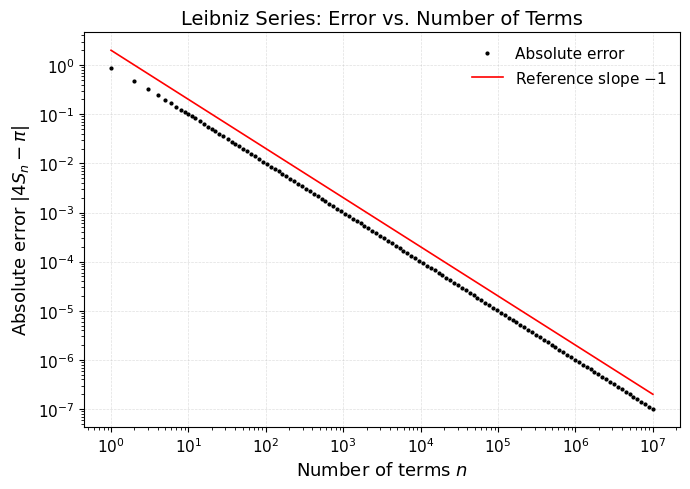

In [11]:
import numpy as np
import math
import matplotlib.pyplot as plt

n_values = np.unique(np.logspace(0, 7, 140).astype(int))

error = np.array([
    abs(4 * leibniz_paired_numpy(int(n)) - math.pi)
    for n in n_values
])

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(
    n_values,
    error,
    ".",
    ms=4,
    color="black",
    label="Absolute error"
)

ax.loglog(
    n_values,
    2.0 / n_values,
    "-",
    lw=1.2,
    color="red",
    label=r"Reference slope $-1$"
)


ax.set_xlabel(r"Number of terms $n$", fontsize=13)
ax.set_ylabel(r"Absolute error $|4S_n-\pi|$", fontsize=13)
ax.set_title("Leibniz Series: Error vs. Number of Terms", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=11)
ax.tick_params(axis="both", which="minor", labelsize=9)
ax.legend(
    fontsize=11,
    loc="upper right",
    frameon=False
)

ax.grid(
    True,
    which="major",
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

fig.tight_layout()
plt.show()

I use the paired NumPy implementation (2j), since it is fast and accurate. Both axes are set to be logarithmic. and the figure is made (`figsize=(7, 5)`) rather than (2,2) as suggested in the instruction, because the figure is too small to read. We can clearly see the convergence behavior.